# Update FrozenLake Environment

In the last notebook, we implemented a model-based reinforcement learning algorithm. For that we created a FrozenLakeEnvironment class where a method `get_transition_prob` returns the transition probabilities of the next states. This setup is known as **model-based** because we or the RL algorithms have access to the transition probability matrix or the environment dynamics prior.

- These types of models are not very practical in real life, because most of the time the transition probabilities of the states are unknown.

- In this notebook, we are going to make the following changes to our `FrozenLakeEnvironment`:
  - change 2d state to 1d state representation
  - add a `find()` method that returns the state where the given cell value, i.e., 'F', 'G', 'S or 'H', exists in the grid. 
  - convert environment from model-based to model-free (remove transition probability returning method to stochastic next-step generator)
  - add rendering feature within the environment for better visualization

Below is the previous FrozenLakeEnvironment without `get_transition_prob()` method

In [1]:
class FrozenLakeEnvironment:
    def __init__(self, grid, reward_points, slippery=True):     
        self.grid = grid

        self.slippery = slippery
        self.action_to_idx = {
                               "left":  0,
                               "down": 1,
                               "right": 2,
                               "up": 3
                            }
        self.action_idx_to_name = {v:k for k,v in self.action_to_idx.items()}
        
        self.reward_points = reward_points
        
        self.terminal_states = ["G", "H"] 
        
        self.action_idx_to_step = {
             0: (0, -1), 
             1: (1, 0),
             2: (0, 1),
             3: (-1, 0)
        }

        self.all_action_idx = list(self.action_to_idx.values())
        self.n_actions = len(self.action_to_idx)
        self.n_rows = len(self.grid)
        self.n_cols = len(self.grid[0])
        self.n_states = self.n_rows * self.n_cols
        self._display_handle = None

    #  ==== we will modify this function to take the State object instead of 2D states ====
    def move(self, current_state, action_idx):
        r, c = current_state
        # Note that we are representing state as a combination of row idx and column idx like a coordinate system 
        step_r, step_c = self.action_idx_to_step[action_idx]
        new_r = min(max(0, r+step_r), self.n_rows -1) #make sure step is a valid one
        new_c = min(max(0, c+step_c), self.n_cols -1)
        return new_r, new_c

    #  ==== we will modify this function to take the State object instead of 2D states ====
    def is_terminal_state(self, state):
        r, c = state
        return self.grid[r][c] in self.terminal_states


## change the 2d state (row, column) representation into 1D

For this, let's create a state class which stores both 1D and 2D representations.

In [2]:
class State:
    def __init__(self, state, n_cols):
        self.n_cols = n_cols
        
        if isinstance(state, (list, tuple)) and len(state) == 2: # 2D state is provided
            self.coord = state
            self.idx = self.get_1d_state(state, self.n_cols)
        else: #1d state is provided
            self.idx = state
            self.coord = self.get_2d_state(state, self.n_cols)

    @classmethod
    def get_1d_state(cls, state_coord, n_cols):
        """
        Converts (row, col) to a single integer index.
        
        Args:
            state_coords (tuple): (row, col)
            n_cols (int): Number of columns in the grid
        """
        r, c = state_coord
        return r * n_cols + c

    @classmethod
    def get_2d_state(cls, state_index, n_cols):
        """
        Converts a single integer index back to (row, col).
        
        Args:
            state_index (int): The 1D state representation
            n_cols (int): Number of columns in the grid
        """
        r = state_index // n_cols
        c = state_index % n_cols
        return (r, c)

In [3]:
state = State(1, 2)
print("1D state: ", state.idx)
print("2D state: ", state.coord)

1D state:  1
2D state:  (0, 1)


In [4]:
State.get_1d_state((1, 2), 5)

7

In [5]:
State.get_2d_state(7, 5)

(1, 2)

Now, let's see the mapping of 1D to 2D states of 4x4 grid. For 4x4 grid we will have 4*4 = 16 1D states.

In [6]:
x = {}
n_rows = 4
n_cols = 4
n_states = n_rows*n_cols
for i in range(n_states):
    x[i] = State(i, n_cols).coord

In [7]:
x

{0: (0, 0),
 1: (0, 1),
 2: (0, 2),
 3: (0, 3),
 4: (1, 0),
 5: (1, 1),
 6: (1, 2),
 7: (1, 3),
 8: (2, 0),
 9: (2, 1),
 10: (2, 2),
 11: (2, 3),
 12: (3, 0),
 13: (3, 1),
 14: (3, 2),
 15: (3, 3)}

## Convert model-based into model-free

We have already removed the `get_transition_prob()` method from the class. Now, let's create a step method which takes the current state and the action. and return the next state along with the reward and a flag determining whether the returned next state is a terminate state or not i.e. `G` or `H`. 

If you remember, **get_transition_prob()** returns all the possible states with probability (i.e., transition probabilities), but this time the environment is going to return only the next states. Note that the next state itself is going to be stochastic or deterministic based on the `slippery` flag. 

In [8]:
import random

In [9]:
def move(self, current_state, action_idx):
    r, c = current_state.coord
    # Note that we are representing state as a combination of row idx and column idx like a coordinate system 
    step_r, step_c = self.action_idx_to_step[action_idx]
    new_r = min(max(0, r+step_r), self.n_rows -1) #make sure step is a valid one
    new_c = min(max(0, c+step_c), self.n_cols -1)
    new_state = State((new_r, new_c), self.n_cols)
    return new_state

def is_terminal_state(self, state):
    r, c = state.coord
    return self.grid[r][c] in self.terminal_states

def get_reward_point(self, state):
    r, c = state.coord
    cell = self.grid[r][c]
    reward_point = self.reward_points.get(cell) or 0.0
    return cell, reward_point

In [10]:
def step(self, current_state, action):
    """
    The core Model-Free interface. 
    Agent provides an action, environment returns (next_state, reward, done).
    """
    
    if is_terminal_state(self, current_state):
        return {"new_state": current_state,
                "reward": 0,
                "is_terminated": True}
                
    actual_action = action
    if self.slippery:
        # 70% chance of success, 10% chance for each other direction
        roll = random.random()
        if roll < 0.7: # 70%
            actual_action = action
        elif roll < 0.8: # 10%
            actual_action = (action + 1) % self.n_actions
        elif roll < 0.9: # 10%
            actual_action = (action + 2) % self.n_actions
        else: # 10%
            actual_action = (action + 3) % self.n_actions
    else:
        actual_action = action
    
    new_state = move(self, current_state, actual_action)
    cell, reward = get_reward_point(self, new_state)
    game_over = cell in ["H", "G"]
    return {"new_state": new_state,
            "reward": reward,
            "is_terminated": game_over}

In [11]:
grid = [['F', 'H', 'F', 'S'],
        ['F', 'F', 'F', 'G'],
        ['F', 'F', 'F', 'F'],
        ['F', 'H', 'F', 'F']]

reward_points = {
                    "G": 1,
                    "F": 0,
                    "H": 0
                }

stochastic_env = FrozenLakeEnvironment(grid, reward_points, slippery=True)
deterministic_env = FrozenLakeEnvironment(grid, reward_points, slippery=False)

In [12]:
state = State(0, 5) # state (0, 0)
action = 2 # moving right

# since the environment is deterministic, all the time you move from state (0, 0) to right you will reach (0, 1)
result = step(deterministic_env, state, action)

print("new state coord: ", result["new_state"].coord)
print("new state reward: ", result["reward"])
print("new state is_terminated: ", result["is_terminated"])

new state coord:  (0, 1)
new state reward:  0.0
new state is_terminated:  True


In [13]:
state = State((1, 2), 5) # state (1, 2)
action = 2 # moving right

# since the environment is deterministic, all the time you move from state (0, 0) to right you will reach (0, 1)
result = step(stochastic_env, state, action)

print("prev state coord: ", state.coord)
print("new state coord: ", result["new_state"].coord)
print("new state reward: ", result["reward"])
print("new state is_terminated: ", result["is_terminated"])

prev state coord:  (1, 2)
new state coord:  (1, 3)
new state reward:  1
new state is_terminated:  True


## Add find() method

In [14]:
 def find(self, value):
    """
    Find the position of a given value in the grid.

    Iterates through the grid and returns the first (row, column)
    coordinate where the specified value is found.

    Args:
        value (str): The grid cell value to search for
            (e.g., 'S', 'G', 'H', 'F').

    Returns:
        tuple[int, int] | None: The (row, column) position of the value
        if found; otherwise, None.
    
    """
    for r in range(self.n_rows):
        for c in range(self.n_cols):
            if self.grid[r][c] == value:
                return State((r, c), self.n_cols)

In [15]:
start_state = find(stochastic_env, 'S')

print("env grid: ", stochastic_env.grid)
print("start state: ", start_state.coord)

env grid:  [['F', 'H', 'F', 'S'], ['F', 'F', 'F', 'G'], ['F', 'F', 'F', 'F'], ['F', 'H', 'F', 'F']]
start state:  (0, 3)


## Render method
We will be visualizing the environment and learning progress during model training

In [16]:
import time
import pandas as pd
from IPython.display import HTML
from matplotlib import pyplot as plt

For this implementation we are going to represent policy as a 1D matrix where idx corresponds to the state 1d idx and the value represents the action index. 


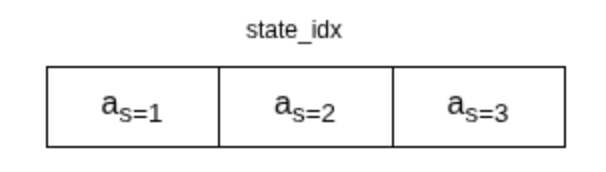

In [17]:
def render(self, policy, current_state, episode_num=0, step_num=0,
               total_reward=0, sleep_time=0.0001):
            
    rows, cols = self.n_rows, self.n_cols
    icons = {"S": "🚀", "H": "🕳️", "G": "🏁", "F": "❄️"}
    arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}

    grid_display = []
    for r in range(rows):
        row_display = []
        for c in range(cols):
            tile = self.grid[r][c]
            if (r, c) == current_state.coord:
                content = "🤖"
                
            elif tile in ["S", "F"]:
                state_idx = State.get_1d_state((r, c), self.n_cols)
                action = policy[state_idx]
                content = f"{icons[tile]} {arrows[action]}"
            else:
                content = icons[tile]
            row_display.append(content)
        grid_display.append(row_display)

    df = pd.DataFrame(grid_display)

    def style_cells(val):
        style = 'width: 60px; height: 60px; text-align: center; font-size: 20px; border: 1px solid #dee2e6;'
        if "🤖" in val: return style + 'background-color: #fff3cd; border: 2px solid #ffc107;' 
        if "🏁" in val: return style + 'background-color: #d4edda;' 
        if "🕳️" in val: return style + 'background-color: #f8d7da;' 
        return style + 'background-color: #89cfef;'

    # Generate the styled HTML for the table
    styled_html = df.style.map(style_cells).to_html()
    
    # Combine Header and Table into one HTML string
    header_html = f"<div style='font-family: sans-serif; margin-bottom: 10px;'>" \
                  f"<b>Episode:</b> {episode_num} | <b>Step:</b> {step_num} | <b>Score:</b> {total_reward}</div>"
    
    full_output = HTML(header_html + styled_html)

    if self._display_handle is None:
        # First time: display the combined HTML and capture handle
        self._display_handle = display(full_output, display_id=True)
    else:
        # Subsequent steps: update the same handle with the new combined HTML
        self._display_handle.update(full_output)
    
    time.sleep(sleep_time)

In [18]:
policy = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

stochastic_env. _display_handle = None

In [19]:
render(stochastic_env, policy, state)

,0,1,2,3
0,❄️ ←,🕳️,❄️ ←,🚀 ←
1,❄️ ←,❄️ ←,🤖,🏁
2,❄️ ←,❄️ ←,❄️ ←,❄️ ←
3,❄️ ←,🕳️,❄️ ←,❄️ ←


In [20]:
policy = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

stochastic_env._display_handle = None # need to reset the _display_handle inorder to display it

render(stochastic_env, policy, state)

,0,1,2,3
0,❄️ ↓,🕳️,❄️ ←,🚀 ←
1,❄️ ←,❄️ ←,🤖,🏁
2,❄️ ←,❄️ ←,❄️ ←,❄️ ←
3,❄️ ←,🕳️,❄️ ←,❄️ ←


# Wrap everything wintin a FrozenLakeEnvironment class

In [21]:
class State:
    def __init__(self, state, n_cols):
        self.n_cols = n_cols
        
        if isinstance(state, (list, tuple)) and len(state) == 2: # 2D state is provided
            self.coord = state
            self.idx = self.get_1d_state(state, self.n_cols)
        else: #1d state is provided
            self.idx = state
            self.coord = self.get_2d_state(state, self.n_cols)

    @classmethod
    def get_1d_state(cls, state_coord, n_cols):
        """
        Converts (row, col) to a single integer index.
        
        Args:
            state_coords (tuple): (row, col)
            n_cols (int): Number of columns in the grid
        """
        r, c = state_coord
        return r * n_cols + c

    @classmethod
    def get_2d_state(cls, state_index, n_cols):
        """
        Converts a single integer index back to (row, col).
        
        Args:
            state_index (int): The 1D state representation
            n_cols (int): Number of columns in the grid
        """
        r = state_index // n_cols
        c = state_index % n_cols
        return (r, c)

In [22]:
class FrozenLakeEnvironment:
    def __init__(self, grid, reward_points, slippery=True):     
        self.grid = grid

        self.slippery = slippery
        self.action_to_idx = {
                               "left":  0,
                               "down": 1,
                               "right": 2,
                               "up": 3
                            }
        self.action_idx_to_name = {v:k for k,v in self.action_to_idx.items()}
        
        self.reward_points = reward_points
        
        self.terminal_states = ["G", "H"] 
        
        self.action_idx_to_step = {
             0: (0, -1), 
             1: (1, 0),
             2: (0, 1),
             3: (-1, 0)
        }

        self.all_action_idx = list(self.action_to_idx.values())
        self.n_actions = len(self.action_to_idx)
        self.n_rows = len(self.grid)
        self.n_cols = len(self.grid[0])
        self.n_states = self.n_rows * self.n_cols
        self._display_handle = None

    def find(self, value):
        """
        Find the position of a given value in the grid.
    
        Iterates through the grid and returns the first (row, column)
        coordinate where the specified value is found.
    
        Args:
            value (str): The grid cell value to search for
                (e.g., 'S', 'G', 'H', 'F').
    
        Returns:
            tuple[int, int] | None: The (row, column) position of the value
            if found; otherwise, None.
        
        """
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                if self.grid[r][c] == value:
                    return State((r, c), self.n_cols)

    def move(self, current_state, action_idx):
        r, c = current_state.coord
        # Note that we are representing state as a combination of row idx and column idx like a coordinate system 
        step_r, step_c = self.action_idx_to_step[action_idx]
        new_r = min(max(0, r+step_r), self.n_rows -1) #make sure step is a valid one
        new_c = min(max(0, c+step_c), self.n_cols -1)
        new_state = State((new_r, new_c), self.n_cols)
        return new_state
    
    def is_terminal_state(self, state):
        r, c = state.coord
        return self.grid[r][c] in self.terminal_states
    
    def get_reward_point(self, state):
        r, c = state.coord
        cell = self.grid[r][c]
        reward_point = self.reward_points.get(cell) or 0.0
        return cell, reward_point


    def step(self, current_state, action):
        """
        The core Model-Free interface. 
        Agent provides an action, environment returns (next_state, reward, done).
        """
        
        if self.is_terminal_state(current_state):
            return {"new_state": current_state,
                    "reward": 0,
                    "is_terminated": True}
                    
        actual_action = action
        if self.slippery:
            # 70% chance of success, 10% chance for each other direction
            roll = random.random()
            if roll < 0.7: # 70%
                actual_action = action
            elif roll < 0.8: # 10%
                actual_action = (action + 1) % self.n_actions
            elif roll < 0.9: # 10%
                actual_action = (action + 2) % self.n_actions
            else: # 10%
                actual_action = (action + 3) % self.n_actions
        else:
            actual_action = action
        
        new_state = self.move(current_state, actual_action)
        cell, reward = self.get_reward_point(new_state)
        is_terminated = cell in ["H", "G"]
        return {"new_state": new_state,
                "reward": reward,
                "is_terminated": is_terminated}

    def render(self, policy, current_state, episode_num=0, step_num=0,
                   total_reward=0, sleep_time=0.0001):
                
        rows, cols = self.n_rows, self.n_cols
        icons = {"S": "🚀", "H": "🕳️", "G": "🏁", "F": "❄️"}
        arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    
        grid_display = []
        for r in range(rows):
            row_display = []
            for c in range(cols):
                tile = self.grid[r][c]
                if (r, c) == current_state.coord:
                    content = "🤖" 
                elif tile in ["S", "F"]:
                    state_idx = State.get_1d_state((r, c), self.n_cols)
                    action = policy[state_idx]
                    content = f"{icons[tile]} {arrows[action]}"
                else:
                    content = icons[tile]
                row_display.append(content)
            grid_display.append(row_display)
    
        df = pd.DataFrame(grid_display)
    
        def style_cells(val):
            style = 'width: 60px; height: 60px; text-align: center; font-size: 20px; border: 1px solid #dee2e6;'
            if "🤖" in val: return style + 'background-color: #fff3cd; border: 2px solid #ffc107;' 
            if "🏁" in val: return style + 'background-color: #d4edda;' 
            if "🕳️" in val: return style + 'background-color: #f8d7da;' 
            return style + 'background-color: #89cfef;'
    
        # Generate the styled HTML for the table
        styled_html = df.style.map(style_cells).to_html()
        
        # Combine Header and Table into one HTML string
        header_html = f"<div style='font-family: sans-serif; margin-bottom: 10px;'>" \
                      f"<b>Episode:</b> {episode_num} | <b>Step:</b> {step_num} | <b>Score:</b> {total_reward}</div>"
        
        full_output = HTML(header_html + styled_html)
    
        if self._display_handle is None:
            # First time: display the combined HTML and capture handle
            self._display_handle = display(full_output, display_id=True)
        else:
            # Subsequent steps: update the same handle with the new combined HTML
            self._display_handle.update(full_output)
        
        time.sleep(sleep_time)

In [23]:
grid = [['F', 'H', 'F', 'S'],
        ['F', 'F', 'F', 'G'],
        ['F', 'F', 'F', 'F'],
        ['F', 'H', 'F', 'F']]

reward_points = {
    "G": 1,
    "F": 0,
    "H": 0
}

env = FrozenLakeEnvironment(grid, reward_points)

print("Number of rows: ", env.n_rows)
print("Number of columns: ", env.n_cols)
print("Number of states: ", env.n_states)
print("Number of actions: ", env.n_actions)

current_state = State((1, 2), env.n_cols)
action_idx = env.action_to_idx["left"]

result = env.step(current_state, action_idx)
print("next state: ", result["new_state"].coord)
print("reward: ", result["reward"])
print("is terminal state? :", result["is_terminated"])

Number of rows:  4
Number of columns:  4
Number of states:  16
Number of actions:  4
next state:  (1, 1)
reward:  0.0
is terminal state? : False


In [24]:
policy = [0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

env._display_handle = None # need to reset the _display_handle inorder to display it

env.render(policy, current_state)

,0,1,2,3
0,❄️ ←,🕳️,❄️ ←,🚀 ↓
1,❄️ ←,❄️ ←,🤖,🏁
2,❄️ ←,❄️ ↓,❄️ ←,❄️ ←
3,❄️ ←,🕳️,❄️ ←,❄️ ←


# In conclusion
In this notebook we have successfully updated the frozenlake environment and we will be using this FrozenLakeEnvironment class to upcoming notebooks.